In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/aeshnadhiman99-wq/Titanic-ML--Assignment-/refs/heads/main/Titanic-Dataset.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
df.loc[:, "Age"] = df["Age"].fillna(df["Age"].median())
df.loc[:, "Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop_duplicates()
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


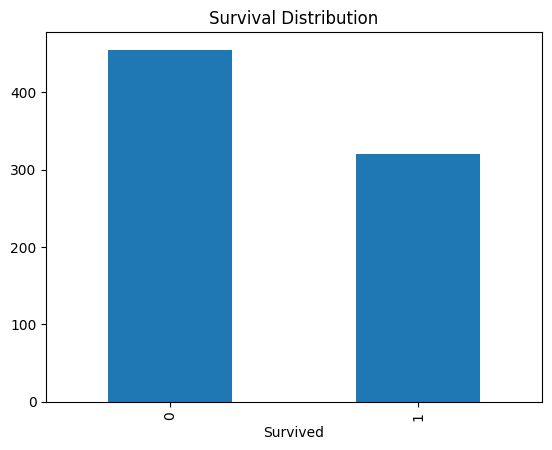

In [ ]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.show()

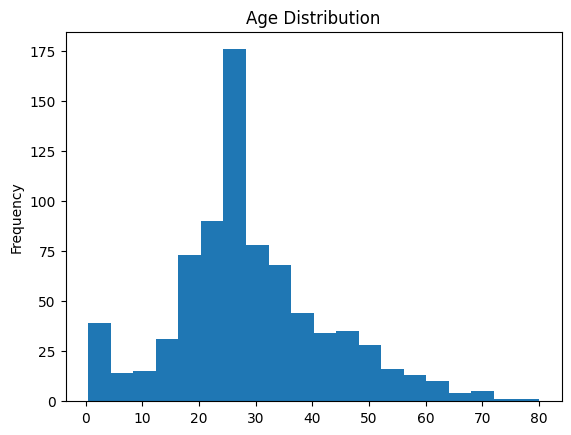

In [ ]:
df["Age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.show()

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
from sklearn.metrics import classification_report
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(lr.predict(X_test),y_test)
pd.DataFrame({"Model":["Logistic Regression"], "Accuracy":[lr_acc]})
print("report :\n", classification_report(y_test,lr.predict(X_test)))

[0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 1
 0 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 1 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 1 0 0] 477    0
813    0
353    0
879    1
396    0
      ..
158    0
360    0
523    1
314    0
652    0
Name: Survived, Length: 155, dtype: int64
report :
               precision    recall  f1-score   support

           0       0.82      0.81      0.81        95
           1       0.70      0.72      0.71        60

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155



In [50]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print(knn.predict(X_test), y_test)
pd.DataFrame({"Model":["KNN"], "Accuracy":[knn_acc]})
print("report :\n", classification_report(y_test, knn.predict(X_test)))

[0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 1 0 1
 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 1 1 1 0 0 0
 1 0 0 0 1 0 0] 477    0
813    0
353    0
879    1
396    0
      ..
158    0
360    0
523    1
314    0
652    0
Name: Survived, Length: 155, dtype: int64
report :
               precision    recall  f1-score   support

           0       0.79      0.85      0.82        95
           1       0.74      0.65      0.69        60

    accuracy                           0.77       155
   macro avg       0.76      0.75      0.76       155
weighted avg       0.77      0.77      0.77       155



In [51]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(dt.predict(X_test), y_test)
pd.DataFrame({"Model":["Decision Tree"], "Accuracy":[dt_acc]})
print("report :\n", classification_report(y_test, dt.predict(X_test)))

[0 1 0 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1 1 0 1 1 0 1
 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 0 0 1
 0 0 0 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 1 0 1 1
 0 1 1 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 1 0 0 0 1
 1 0 1 0 1 0 0] 477    0
813    0
353    0
879    1
396    0
      ..
158    0
360    0
523    1
314    0
652    0
Name: Survived, Length: 155, dtype: int64
report :
               precision    recall  f1-score   support

           0       0.79      0.75      0.77        95
           1       0.63      0.68      0.66        60

    accuracy                           0.72       155
   macro avg       0.71      0.72      0.71       155
weighted avg       0.73      0.72      0.72       155



In [52]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(rf.predict(X_test), y_test)
pd.DataFrame({"Model":["Random Forest"], "Accuracy":[rf_acc]})
print("report :\n", classification_report(y_test, rf.predict(X_test)))

[0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1
 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 0 0 1
 0 0 0 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1
 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 1 0 0 0 0
 1 0 1 0 1 0 0] 477    0
813    0
353    0
879    1
396    0
      ..
158    0
360    0
523    1
314    0
652    0
Name: Survived, Length: 155, dtype: int64
report :
               precision    recall  f1-score   support

           0       0.78      0.81      0.79        95
           1       0.68      0.63      0.66        60

    accuracy                           0.74       155
   macro avg       0.73      0.72      0.72       155
weighted avg       0.74      0.74      0.74       155



In [54]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_acc, knn_acc, dt_acc, rf_acc]
})

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.774194
1,KNN,0.774194
3,Random Forest,0.741935
2,Decision Tree,0.722581


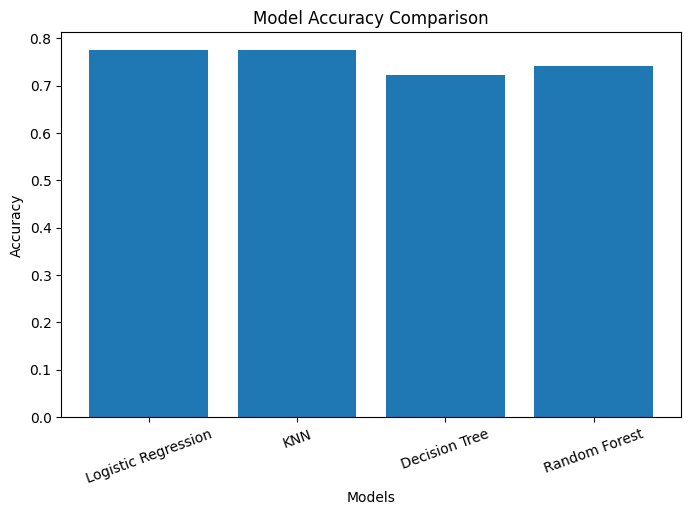

In [55]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [56]:
results_df.sort_values(by="Accuracy", ascending=False).head(1)

,Model,Accuracy
0,Logistic Regression,0.774194
